# Effects of Non-Sperical Earth

## Sphere, Ellipsoid and Geoid
The concept of spherical Earth is only valid for a first-order approximation of the equations of motion. By the late 1600s, serious effort was devoted to modeling the Earth as an **ellipsoid**. As theorized by Isaac Newton and Christiaan Huygens, the Earth is flattened at the poles and bulged at the equator. Thus, a more accurate model is the oblate ellipsoid, an ellipsoid of revolution obtained by rotating an ellipse about its shorter axis. It is the regular geometric shape that most nearly approximates the shape of the Earth. A spheroid describing the figure of the Earth or other celestial body is called **reference ellipsoid**.

An ellipsoid is uniquely defined by two quantities. Several conventions for expressing the two quantities are used in geodesy, but they are all equivalent and convertible with each other:

- Equatorial radius *a* and polar radius *b*
- Equatorial radius *a* and eccentricity *e*
- Equatorial radius *a* and flattening *f*

, where the flattening is defined as $$f=\frac{a-b}{a}$$.

Eccentricity and flattening are different ways of expressing how squashed the ellipsoid is. When flattening appears as one of the defining quantities in geodesy, generally it is expressed by its reciprocal. For example, in the **WGS 84** spheroid used by today's GPS systems, a=6378.137 km and b=6356.752 km; the reciprocal of the flattening *1/f* is set to be exactly 298.257223563.

&nbsp;  

<center><img src="Images/ellipsoid.png" alt="Drawing" style="width: 350px;"/><center>



The introduction of the ellipsoid leads to two different definition for the latitude:

- **Geodetic** latitude:uses the normal to the ellipsoid, acting as a plumb line
- **Geocentric** latitude: uses a radius straight from the center of the Earth

<center><img src="Images/latitude.png" alt="Drawing" style="width: 500px;"/><center>
    
While the ellipsoid is a mathematically defined regular surface, we here introduce the **geoid**, which coincides with the surface the oceans would have over the entire Earth. As a result of the uneven distribution of the Earth's mass, the geoidal surface is irregular and, since the ellipsoid is a regular surface, the separations between the two will be irregular as well.


The video below shows an animation based on available gravity measurements from the GOCE (Gravity Field and Steady-State Ocean Circulation Explorer)mission. The Earth's geoid is mapped with a precision of 1 cm over 100 km.

In [1]:
from IPython.display import HTML
HTML(f"""
<div style="display: flex; justify-content: center;">
    <video width="700" height="500" controls>
        <source src="Images/geoid.mp4" type="video/mp4">
    </video>
</div>
""")

The geoid is a surface along which the gravity potential is equal everywhere and to which the direction of gravity is always perpendicular. The figure below highlights the differences between the ellipsoid and the geoid: the level of note as the local plumb line is always perpendicular to the surface of the geoid:

<center><img src="Images/levels.png" alt="Drawing" style="width: 750px;"/><center>

## The Earth Gravitational Potential

### Mathematical Model

The Earth's gravity field harmonics are a mathematical model used to describe the variations in Earth's gravitational field. Unlike a perfect sphere with uniform gravity, Earth has a complex gravitational field due to its uneven mass distribution. We define:

- $\phi$ = declination from equatorial plane
- $r$ = distance of a point mass to the ellipsoid center
- $\lambda$ = right ascension measured from Greenwich meridian

<center><img src="Images/ECEF.png" alt="Drawing" style="width: 550px;"/><center>





The gravitational potential ($U$) at a point in space is represented by a spherical harmonic expansion:

$$U(r, \phi, \lambda) = \frac{GM}{r} \left[ 1 + \sum_{l=2}^{\infty} \sum_{m=0}^{l} \left( \frac{R}{r} \right)^l P_{lm}(\sin\phi) (\bar{C}_{lm}\cos(m\lambda) + \bar{S}_{lm}\sin(m\lambda)) \right]$$

, where:

* **$GM/r$** is the dominant term, representing the gravity of a perfect, uniform sphere
* **$G$** is the gravitational constant and **$M$** is Earth's mass
* **$r, \phi, \lambda$** are the spherical coordinates (radius, latitude, and longitude)
* **$l$ and $m$** are the **degree ($l$)** and **order ($m$)** of the harmonic
    * **Degree ($l$)** describes the size of the feature. Terms with low degrees (e.g., $l=2, 3, 4, 5$) describe global-scale features like the equatorial bulge, the light pear shape of the Earth and the north-south asymmetry, while terms with high degrees ($l > 10$) describe localized variations in gravity caused by mountain ranges, deep ocean trenches, and continental shifts
    * **Order ($m$)** describes the longitudinal variation
* **$P_{lm}$** represens the associated Legendre functions of degree $l$ and order $m$. They define the geometric shape and spatial distribution of the gravitational potential across the sphere
* **$\bar{C}_{lm}$ and $\bar{S}_{lm}$** are the **gravity field coefficients**, a set of numbers that define the strength and shape of each harmonic term. They are derived by fitting the model to satellite tracking data.


This representation is broken down into three mathematical parts:

1.  **Radial dependence ($1/r^{l+1}$):** how the gravity changes with distance from the center
2.  **Longitudinal dependence ($\cos(m\lambda)$ and $\sin(m\lambda)$):** how the gravity varies with longitude ($\lambda$)
3.  **Latitudinal dependence ($P_{lm}(\sin\phi)$):** how the gravity varies with latitude ($\phi$)

Modern gravity field models, such as the **EGM2008 (Earth Gravitational Model 2008)**, have been computed to a very high degree and order (up to 2160) using data from dedicated gravity-mapping missions like **GRACE** (Gravity Recovery and Climate Experiment).

## Types of Harmonics

In simpler terms, the Earth's gravitational potential can be imagined as the sum of the potential of a sphere ($\frac{\mu}{r}$) plus three *disturbing* potentials which are function of the location of the point $P$ respect to the Earth Centered, Earth Fixed reference system:

$\quad$

$$U(\phi, \lambda, r) = \frac{\mu}{r} + U_{zonal}(r, \phi) + U_{sectorial}(r, \lambda) + U_{tesseral}(r, \phi, \lambda)$$


In the spherical harmonic expansion, the coefficients are categorized by the relationship between their degree ($l$) and order ($m$):

| Type of Harmonic | Condition | Description | Example Coefficients |
| :--- | :--- | :--- | :--- |
| **Zonal** | $m = 0$ | Describes features that vary only with **latitude** and are symmetric around the poles (like the equatorial bulge). | $\bar{C}_{2,0}, \bar{C}_{3,0}$ |
| **Sectorial** | $\mathbf{l = m}$ and $m > 0$ | Describes features that vary **only with longitude**, dividing the sphere into equal sectors from pole to pole. | $\bar{C}_{2,2}, \bar{C}_{3,3}$ |
| **Tesseral** | $l > m$ and $m > 0$ | Describes features that vary with **both latitude and longitude** (a checkerboard pattern). | $\bar{C}_{3,1}, \bar{C}_{4,2}$ |

$\quad$


### Zonal Harmonics

These are the terms where the order $ m=0$. They are independent of longitude (only depend on $r$ and $\phi$) and describe features that are symmetric around the Earth's rotation axis (like the equatorial bulge). The $J$ notation is primarily used for these zonal terms, where

$$ J_l = -C_{l,0}$$

<center><img src="Images/zonalHarmonics.png" alt="Drawing" style="width: 550px;"/><center>

$\quad$


Below are the values for the first 5 normalized zonal coefficients ($\bar{C}_{l,0}$) of the Earth's gravitational potential, typically taken from a high-resolution model like EGM2008 (Earth Gravitational Model 2008). The first term $J_2$ is by far the strongest perturbation due to the Earth's oblateness around the equator: it is almost 1000 times larger that the next largest coefficient $J_3$, which models the pear-shape of the Earth.

$\quad$

| Degree ($l$) | Coefficient Notation | Value | Description |
| :---: | :---: | :---: | :--- |
| **2** | $\bar{C}_{2,0}$ (or $-J_2$) | -4.8416537488647e-04 | **Equatorial Bulge** (Dominant non-spherical term) |
| **3** | $\bar{C}_{3,0}$ (or $-J_3$) | 9.5717059088800e-07 | **Pear Shape** (North-South asymmetry) |
| **4** | $\bar{C}_{4,0}$ (or $-J_4$) | 5.3977706835730e-07 | Flattening and higher-order bulge effects |
| **5** | $\bar{C}_{5,0}$ (or $-J_5$) | 6.8658987986543e-08 | |

$\quad$

Note as the values above are the *normalized* coefficients ($\bar{C}_{l,0}$), which are the standard form used in modern geodetic models to simplify calculations and improve numerical stability.



### Sectorial Harmonics

These are the terms where $l=m$. Represent bands of longitude around the Earth, being only depend on $r$ and $\lambda$. This effect is used to consider the difference in density between oceans and land masses.

<center><img src="Images/sectorialHarmonics.png" alt="Drawing" style="width: 550px;"/><center>

$\quad$

The $l=m$ condition means the feature has the maximum possible longitudinal variation for that particular degree, resulting in distinct sectors around the equator. For example, the $\bar{C}_{2,2}$ term describes the Earth's **equatorial ellipticity**, which is the most prominent sectorial harmonic.

$\quad$

| Degree ($l$) & Order ($m$) | Coefficient | Value | Physical Feature Represented |
| :---: | :---: | :---: | :--- |
| **$l=2, m=2$** | $\bar{C}_{2,2}$ | -2.439e-06 | **Equatorial Ellipticity** (Size of the equatorial bulge's major axis) |
| **$l=3, m=3$** | $\bar{C}_{3,3}$ | +0.198e-06 | Triangular-like deformation in the equatorial plane |
| **$l=4, m=4$** | $\bar{C}_{4,4}$ | +0.133e-06 | Square-like deformation in the equatorial plane |
| **$l=5, m=5$** | $\bar{C}_{5,5}$ | -0.137e-06 | Pentagonal deformation |
| **$l=6, m=6$** | $\bar{C}_{6,6}$ | +0.081e-06 | Hexagonal deformation |

$\quad$



### Tesseral Harmonics

The last term of the gravitational potential attempts to model the specific regions on Earth which depart from a perfect sphere. This effect is is used to take into account great mass concentration such as mountains. They depend on $r$, $\phi_{gc}$ and $\lambda$.

<center><img src="Images/tesseralHarmonics.png" alt="Drawing" style="width: 550px;"/><center>

$\quad$




## The J2 Perturbation

For simplicity, we ignore all harmonics except the first zonal harmonic. The additional effect due to $J2$ to the gravitational potential become

$$\Delta U(\phi, r) = -\frac{\mu}{r}J_2\left ( \frac{R_e}{r} \right ) ^3  \left [ \frac{3}{2} \sin^{2} \phi-\frac{1}{2}\right ]$$

By referring this equation to a coordinate system called **RTN** (Radial-Transverse-Normal) and averaging the effect over a full orbital period, we get the analytical description of the $J2$ secular effects.

### J2 effects - Nodal regression

Nodal precession is the precession of an orbital plane around the rotation axis of an astronomical body such as Earth. The direction of precession is opposite the direction of revolution. For a typical prograde (in the direction of central body rotation) orbit around Earth, the longitude of the ascending node decreases, i.e., node precesses westward. If the orbit is retrograde, this increases the longitude of the ascending node, i.e., node precesses eastward.

<center><img src="Images/nodalRegression.png" alt="Drawing" style="width: 550px;"/><center>

The nodal precession rate is function of the orbit's size, shape, and inclination:

 $$ \frac{d\Omega }{dt}=-\left ( \frac{3}{2} \right )J_{2}\frac{R_{e}^{2}}{\left ( a\left ( 1-e^{2} \right ) \right) ^{2}} \sqrt{\frac{\mu }{a^{3}}} \cos i$$

Any non-polar orbit ($i$ = 90°) will be subject to nodal regression. Since the orbit period is

 $$T=2\pi\sqrt{\frac{a^3}{\mu}}$$

we can calculate the value of the nodal regression over an entire orbit period:

$$ \frac{\Delta \Omega }{T}=- 3 \pi \frac{J_2 R_{e}^2}{\left ( a\left ( 1-e^{2} \right ) \right) ^{2}} \cos i$$

The code below calculates the nodal regression per solar day, as funciton of $a$ and $i$

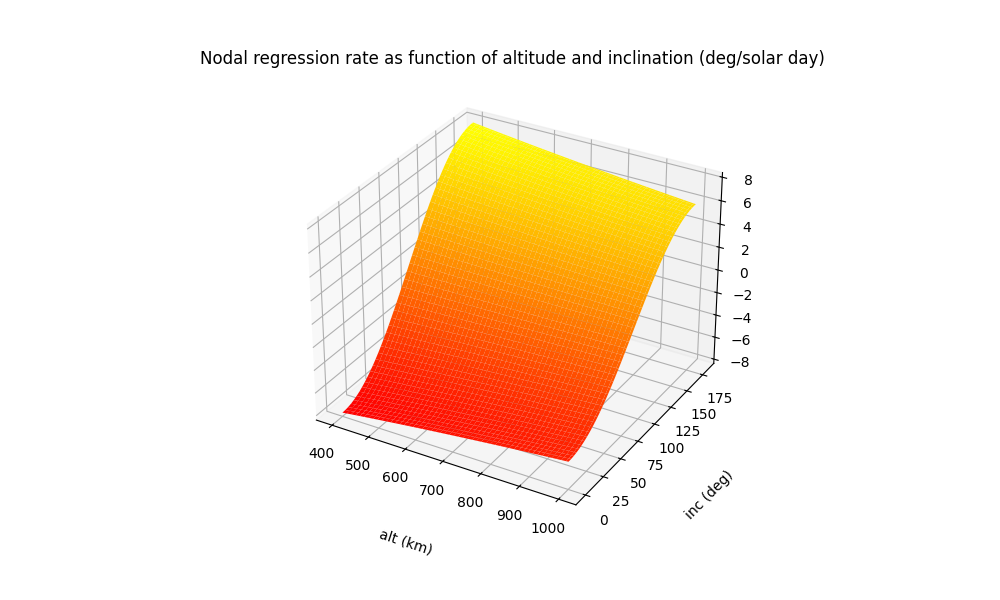

In [2]:
from routines import *
%matplotlib widget

########################################## INPUT DATA ##########################################################
minAlt = 400 #km
maxAlt = 1000 #km
minInc = 0   #deg
maxInc = 180 #deg
ecc = 0
################################################################################################################

PlotNodalRegression(minAlt, maxAlt, minInc, maxInc, ecc)

### J2 effects - Apsidal Rotation

The apsidal rotation is related with the secular change of the argument of perigee. It is function of the orbit's size, shape, and inclination:

 $$ \frac{d\omega }{dt}=\left ( \frac{3}{2} \right )J_{2}\frac{R_{e}^{2}}{\left ( a\left ( 1-e^{2} \right ) \right) ^{2}} \sqrt{\frac{\mu }{a^{3}}}(2-\frac{5}{2}sin^{2}i)$$

&nbsp;  

<center><img src="Images/apsidalRotation.png" alt="Drawing" style="width: 550px;"/><center>


Accordingly, the apsidal rotation over an entire period is:

$$ \frac{\Delta \omega }{\Delta T}= 3 \pi \frac{J_2 R_{e}^2}{\left ( a\left ( 1-e^{2} \right ) \right) ^{2}}  \left ( 2 - \frac{5}{2} \sin^{2} i\right )$$

For most of the cases of interest we can assume the eccentricity to be zero (circular orbits), so the only independent variables are altitude and inclination:

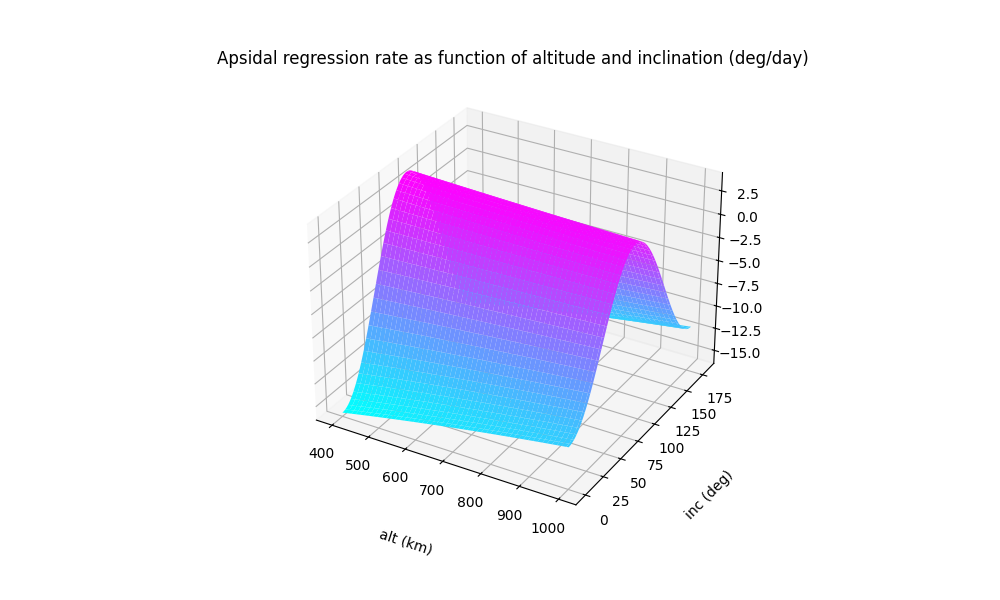

In [3]:
from routines import *
%matplotlib widget

########################################## INPUT DATA ##########################################################
minAlt = 400 #km
maxAlt = 1000 #km
minInc = 0   #deg
maxInc = 180 #deg
ecc = 0
################################################################################################################

PlotApsidalRotation(minAlt, maxAlt, minInc, maxInc, ecc)

## J2 Specialized Orbits

The effect of $J_2$ on node regression and apsidal rotation is used to derive very special orbits:

### Sun-Synchronous Orbits

**Sun-synchronous** or **SSO** orbits keep the line of nodes of the satellite's orbit fixed relative to the Sun. In other words, the orbital plane makes a constant angle $\alpha$ respect to the Sun direction. A Sun-synchronous orbit is useful for imaging, reconnaissance, and weather satellites because every time that the satellite is passing over a point of interest the surface illumination angle on the planet underneath it is nearly the same.

<center><img src="Images/sso.png" alt="Drawing" style="width: 650px;"/><center>

To get an SSO orbit, the orbit's nodal precession rate shall match the angular velocity of the Earth in its orbit around the Sun, which is 360° per 365.2421 days; we get:

$$ \dot{\Omega}_{SunSyn} = 1.991063853*10^{-7} \frac{rad}{sec}$$

Accordingly with the equation disussed above, the semimajor axis, eccentricity and inclination are related each other. Assuming that we have a requirement on the satellite altitude (so, we have $a$), follows that:

$$\cos i = -2a^{\frac{7}{2}} \frac{\dot{\Omega}_{SunSyn}{\left (\left ( 1-e^{2} \right ) \right) ^{2}}}{3 R_e^2 J_2 \sqrt{\mu}}$$

When $e=0$ we get the following relationship between altitude and inclination:

&nbsp;  

<center><img src="Images/altIncSso.png" alt="Drawing" style="width: 850px;"/><center>


### Repeating Ground Track Orbits

**Repeating Ground Track (RGT)** orbits have ground tracks that exactly repeats their pattern after a certain number of days. RGT configuration is useful for Earth observation and reconnaissance missions because satellite flies periodically over a site on the surface of the Earth. 

Two key properties of the ground track are the **revolutions to repeat** (or equator crossing points) $j$ and the **days to repeat** $k$ with which they occur. There are two factors to consider:

1) The reference time interval is the **nodal period**, which is the time interval the spacecraft takes to make two successive equator crossing. It is slight less than the Keplerian period and is mainly affected by the drift of the argument of perigee:

$$ T_{nodal}= 2 \pi \sqrt{\frac{a^3}{\mu}}\left [ 1-\frac{3}{2} J_2 \left ( \frac{R_e}{a} \right )^2 \left ( 3-4 \sin^{2} i \right )\right ] $$

2) The reference distance is the **groundtrack shift**, the distance between two consecutive equator crossing points:
   
$$ \Delta \lambda = \left ( \omega_e - \dot{\Omega} \right )T_{nodal} $$

This is how far the Earth rotates during the nodal period respect to the ascending node in inertial space, considering the nodal regression $\dot \Omega$. Note that $\omega_e$ is the Earth angular velocity $\omega$ = $2 \pi$/ $ T_{sidereal} = 7.292115e-5 \frac{rad}{sec}$.

The repetition of the ground track pattern is achieved if after $j$ orbital revolution the Earth rotates $k$ times around itself:

$$ j \left ( \omega_e - \dot{\Omega} \right )T_{nodal}= k 2 \pi R_{e} $$

The Figure below shows a RGT pattern relevant to $j$ = 15 and $k$ = 1:

<center><img src="Images/RGT.png" alt="Drawing" style="width: 750px;"/><center>

&nbsp;  

From the operational standpoint, we normally need to satisfy requirements of the longitude shifts at equator, which depends on $j$. For example, Landsat-8 has $j$ = 283, which means the equator is divided into 282 slices whose width is $ 2 \pi R_e$ /$282 = 142.1$ $km$. We then define $k$, the number of days to repeat. This is 16 for Landsat-8, which brings to 282/16 = 17.625 revs/day from which we can derive the semimajor axis.

On the other end, we may have a requirement on the satellite altitude to satisfy payload's related constraints. This implies a well defined semimajor axis and, consequently, a well defined number of orbit revolutions per day. In this case we can use this formula:

$$ N_{nodal} = n + \frac{d}{k}$$

, where $N_{nodal}$ is the nodal orbital frequency (number or revolutions per day), $n$ is the nearest integer number to $N_{nodal}$, $k$ is the number of days to repeat.

We can get the number of orbits to repeat $j$ as in the follow example: $N_{nodal}$ = 15.5 (from altitude requirements) = 15 + 0.15 = 15 + 3/20, so in this case $k$ = 20, $d$ = 3 and $j$ = $N_{nodal} \cdot n + d$ = 15*20+3=303

Note that we can also couple a repeating ground track orbit with a Sun-synchronous orbit. In this case, we first need to find the semimajor axis for the RGT orbit, then we need to iterate the solution until the SSO parameters are satisfied.

Here below are shown as the altitude has an impact on the combination of $j$ and $k$ for SSO/RGT orbits:

<center><img src="Images/RGT2.png" alt="Drawing" style="width: 950px;"/><center>

&nbsp;  

In [4]:
########################################## INPUT DATA ################################################
j = 12 # num. of orbit to repeat
k = 1 # num. of days to repeat
######################################################################################################

# num. of orbit per day
n = j/k
# get period
T = 86400/n
# calculate the SMA
a = ((398600*T*T)/(4*math.pi*math.pi))**(1/3)
# get the altitude
alt = a - 6378.37
print('GTO aLtitude = ' + str(alt) + ' km')

GTO aLtitude = 1680.6243290902703 km


### Critically Inclined Orbits

When $$(2-\frac{5}{2}sin^{2}i) = 0$$ the orbit's apsidal rotation $d \omega / dt$ vanishes. The relevant inclination angles are **63.43°** and **116.57°**. Those are the **critical inclinations** at which the apse line does not move. If 0° ≤ $i$ < 63.43° or 116.57° < $i$ ≤180° then $\omega$ rate of change is positive, which means the perigee advances in the direction of the motion of the satellite. If 63.43° < $i$ ≤ 116.57°, the perigee regresses, moving opposite to the direction of motion. 

This condition is utilized, for example, by the so-called Molniya and Tundra orbits. All these are highly elliptic orbits with orbital periods of exactly 3, 8, 12, and 24 h which are employed for communication services. The Figure below shows an example of Molniya orbit:

<center><img src="Images/molniya.png" alt="Drawing" style="width: 550px;"/><center>


## J3 Specialized Orbits

### Frozen Orbits
Even if the magnitude of $J_3$ is 1000 times smaller than $J2$, it still exterts a combined effect on $e$ and $\omega$. The perturbation equations in this case became:

$$ \frac{de}{dt}=\frac{3}{2}\frac{J_3 {R_e}^3}{a^3 \left ( \left ( 1-e^{2} \right ) \right) ^{2}}n \sin i \cos \omega\left ( \frac{5}{4} {sin}^2 i - 1\right )$$

$$  \frac{d \omega}{dt}=\frac{3}{2}\frac{J_2 R_e^2}{\left ( a\left ( 1-e^2 \right ) \right )^2}n\left ( 2-\frac{5}{2} \sin^2 i\right )$$

, where $n$ is the mean motion.

Defining the conditions $$\frac{de}{dt}=0, \frac{d \omega}{dt}=0$$, we can find the so called **frozen orbits**, which are characterized by the absence of long-term changes in orbital eccentricity and argument of perigee. This type of orbit maintains almost constant altitude over any particular point on a planet’s surface.

#### Type I Frozen Orbits

Those orbits have a very little ecentricity and are normally related to Earth observation missions. The first condition ($ \dot{e}=0 $)  is realized is for specific values of the argument of perigee $$ \cos \omega = 0 \mapsto  \omega = \frac{\pi}{2}, \frac{3 \pi}{2}$$

, so the argument of perigee is "frozen" at 90° (over the North Pole) or 270° (over the South Pole).

Regarding the second condition ($ \dot{omega}=0 $), we need to find the proper eccentricity value that balances the effects of $J_2$ and $J_3$:

$$ \frac{J_2 R_e^2}{\left ( a\left ( 1-e^2 \right ) \right )^2}n\left ( 2-\frac{5}{2} \sin^2 i\right ) = \frac{J_2 R_{e}^{2} \sin \omega}{\left ( a\left ( 1-e^2 \right ) \right )^3 e \sin i}n\left [ \left ( \frac{5}{4} \sin^2 i -1\right ) \sin^2 i + e^2\left ( 1-\frac{35}{4} \sin^2 i \cos^2 i\right ) \right ]$$

This is a nonlinear equation which can be numerically solved to find the needed mean eccentricity for a frozen orbit. It can be demonstrated that, using mean $a$ and $i$,
$$ e_{frozen} \approx -\frac{1}{2}\frac{J_3}{J_2}\frac{R_e}{a} \sin i$$

#### Type II Frozen Orbits

Type II orbits are much more eccentric; they are typically used for specialized communication or scientific missions where the satellite needs to spend a long time over one hemisphere. 
Both conditions are realized when $$\sin i = \sqrt{\frac{4}{5}} \mapsto i=63.4^{\circ}, i=116.6^{\circ}$$

,which is called **critical inclination**. So, **orbits at critial inclination are also frozen**.

Despite the argument of perigee $\omega$ doesn't nedd to be at 90° or 270°, it is popular to put it at 270° to place te apogee over the northern emisphere and provide coverage at high latitudes.
